# Preprocessing ISIC → UNeXt format

Este notebook:
1. **Merges** the `Training_Input`, `Validation_Input`, and `Test_Input` folders (and their GroundTruth)
2. Resizes images and masks to **512×512 px**
3. Organizes in the format expected by UNeXt (`inputs/ISIC/images/` and `inputs/ISIC/masks/0/`)
4. Randomly splits into **2155 train / 539 validation / 1000 test** (if the full dataset is available)
5. Saves each split's IDs in `.txt` files


In [1]:
import os
import random
import numpy as np
import cv2
from glob import glob
from pathlib import Path

print('Libraries loaded.')

Libraries loaded.


In [2]:
# ─── Configuration ─────────────────────────────────────────────────────────────
BASE_DIR   = "/home/bruno/Desktop/training_inference_datasets"
ISIC_DIR   = os.path.join(BASE_DIR, "datasets", "ISIC")
UNEXT_DIR  = os.path.join(BASE_DIR, "UNeXt-pytorch-main")
INPUTS_DIR = os.path.join(UNEXT_DIR, "inputs", "ISIC")

IMG_OUT_DIR  = os.path.join(INPUTS_DIR, "images")
MASK_OUT_DIR = os.path.join(INPUTS_DIR, "masks", "0")

IMG_SIZE = 512   # output resolution (px) — divisible by 32 for UNeXt
SEED     = 42

# Splits desejados (assumindo dataset ISIC 2018 completo: 3694 imagens)
N_TRAIN = 2155
N_VAL   = 539
N_TEST  = 1000

# Folder pairs: (images, masks)
SOURCE_PAIRS = [
    (os.path.join(ISIC_DIR, "Training_Input"),    os.path.join(ISIC_DIR, "Training_GroundTruth")),
    (os.path.join(ISIC_DIR, "Validation_Input"),  os.path.join(ISIC_DIR, "Validation_GroundTruth")),
    (os.path.join(ISIC_DIR, "Test_Input"),         os.path.join(ISIC_DIR, "Test_GroundTruth")),
]

os.makedirs(IMG_OUT_DIR,  exist_ok=True)
os.makedirs(MASK_OUT_DIR, exist_ok=True)

print(f'Image output : {IMG_OUT_DIR}')
print(f'Mask output  : {MASK_OUT_DIR}')

Image output : /home/bruno/Desktop/training_inference_datasets/UNeXt-pytorch-main/inputs/ISIC/images
Mask output  : /home/bruno/Desktop/training_inference_datasets/UNeXt-pytorch-main/inputs/ISIC/masks/0


In [3]:
# ─── Collect all (image, mask) pairs ───────────────────────────────
# ISIC convention: image = ISIC_XXXXXXX.jpg, mask = ISIC_XXXXXXX_segmentation.png

all_pairs = []   # lista de (img_id, img_path, mask_path)

for img_folder, mask_folder in SOURCE_PAIRS:
    img_files = sorted(glob(os.path.join(img_folder, "ISIC_*.jpg")))
    found_src = os.path.basename(img_folder)
    count_ok  = 0

    for img_path in img_files:
        img_id    = os.path.splitext(os.path.basename(img_path))[0]  # 'ISIC_XXXXXXX'
        mask_path = os.path.join(mask_folder, f"{img_id}_segmentation.png")

        if not os.path.exists(mask_path):
            print(f'  [warning] mask not found for {img_id}')
            continue

        all_pairs.append((img_id, img_path, mask_path))
        count_ok += 1

    print(f'  {found_src}: {count_ok} valid pairs')

print(f'\nTotal pairs available: {len(all_pairs)}')
total_target = N_TRAIN + N_VAL + N_TEST
print(f'Total required for the requested split: {total_target}')

if len(all_pairs) < total_target:
    print(f'\n⚠️  Dataset incompleto ({len(all_pairs)} < {total_target}).')
    print('   A proportional split will be applied over available images.')

  Training_Input: 2594 valid pairs
  Validation_Input: 100 valid pairs
  Test_Input: 1000 valid pairs

Total pairs available: 3694
Total required for the requested split: 3694


In [4]:
# ─── Processa e salva todas as imagens no formato UNeXt ──────────────────────
image_ids = []
n_total   = len(all_pairs)

for idx, (img_id, img_path, mask_path) in enumerate(all_pairs):
    if (idx + 1) % 200 == 0 or idx == 0:
        print(f'  Processando {idx + 1}/{n_total}...', flush=True)

    img  = cv2.imread(img_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if img is None or mask is None:
        print(f'  [aviso] falha ao ler {img_id}')
        continue

    # Redimensiona para 512×512
    img_r  = cv2.resize(img,  (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)
    mask_r = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    # Ensure binary values after resize
    mask_r[mask_r > 0] = 255

    # Salva como PNG
    cv2.imwrite(os.path.join(IMG_OUT_DIR,  f'{img_id}.png'), img_r)
    cv2.imwrite(os.path.join(MASK_OUT_DIR, f'{img_id}.png'), mask_r)

    image_ids.append(img_id)

print(f'\nTotal processado com sucesso: {len(image_ids)}')

  Processando 1/3694...
  Processando 200/3694...
  Processando 400/3694...
  Processando 600/3694...
  Processando 800/3694...
  Processando 1000/3694...
  Processando 1200/3694...
  Processando 1400/3694...
  Processando 1600/3694...
  Processando 1800/3694...
  Processando 2000/3694...
  Processando 2200/3694...
  Processando 2400/3694...
  Processando 2600/3694...
  Processando 2800/3694...
  Processando 3000/3694...
  Processando 3200/3694...
  Processando 3400/3694...
  Processando 3600/3694...

Total processado com sucesso: 3694


In [5]:
# ─── Random split ──────────────────────────────────────────────────────────
random.seed(SEED)
shuffled = image_ids.copy()
random.shuffle(shuffled)

total  = len(shuffled)
target = N_TRAIN + N_VAL + N_TEST

if total >= target:
    n_train, n_val, n_test = N_TRAIN, N_VAL, N_TEST
    if total > target:
        print(f'[info] {total - target} images not used in any split.')
else:
    # Proportional split maintaining the requested ratios
    ratio   = total / target
    n_train = round(N_TRAIN * ratio)
    n_val   = round(N_VAL   * ratio)
    n_test  = total - n_train - n_val
    print(f'[aviso] Split proporcional aplicado (fator={ratio:.3f}).')

train_ids = shuffled[:n_train]
val_ids   = shuffled[n_train : n_train + n_val]
test_ids  = shuffled[n_train + n_val : n_train + n_val + n_test]

print(f'\nTreino    : {len(train_ids)}')
print(f'Validation: {len(val_ids)}')
print(f'Teste     : {len(test_ids)}')
print(f'Total usado: {len(train_ids) + len(val_ids) + len(test_ids)} de {total}')


Treino    : 2155
Validation: 539
Teste     : 1000
Total usado: 3694 de 3694


In [6]:
# ─── Salva IDs dos splits ─────────────────────────────────────────────────────
splits = {"train": train_ids, "val": val_ids, "test": test_ids}

for split_name, ids in splits.items():
    out_path = os.path.join(INPUTS_DIR, f"{split_name}_ids.txt")
    with open(out_path, 'w') as f:
        f.write('\n'.join(ids))
    print(f'Salvo: {out_path}  ({len(ids)} IDs)')

Salvo: /home/bruno/Desktop/training_inference_datasets/UNeXt-pytorch-main/inputs/ISIC/train_ids.txt  (2155 IDs)
Salvo: /home/bruno/Desktop/training_inference_datasets/UNeXt-pytorch-main/inputs/ISIC/val_ids.txt  (539 IDs)
Salvo: /home/bruno/Desktop/training_inference_datasets/UNeXt-pytorch-main/inputs/ISIC/test_ids.txt  (1000 IDs)


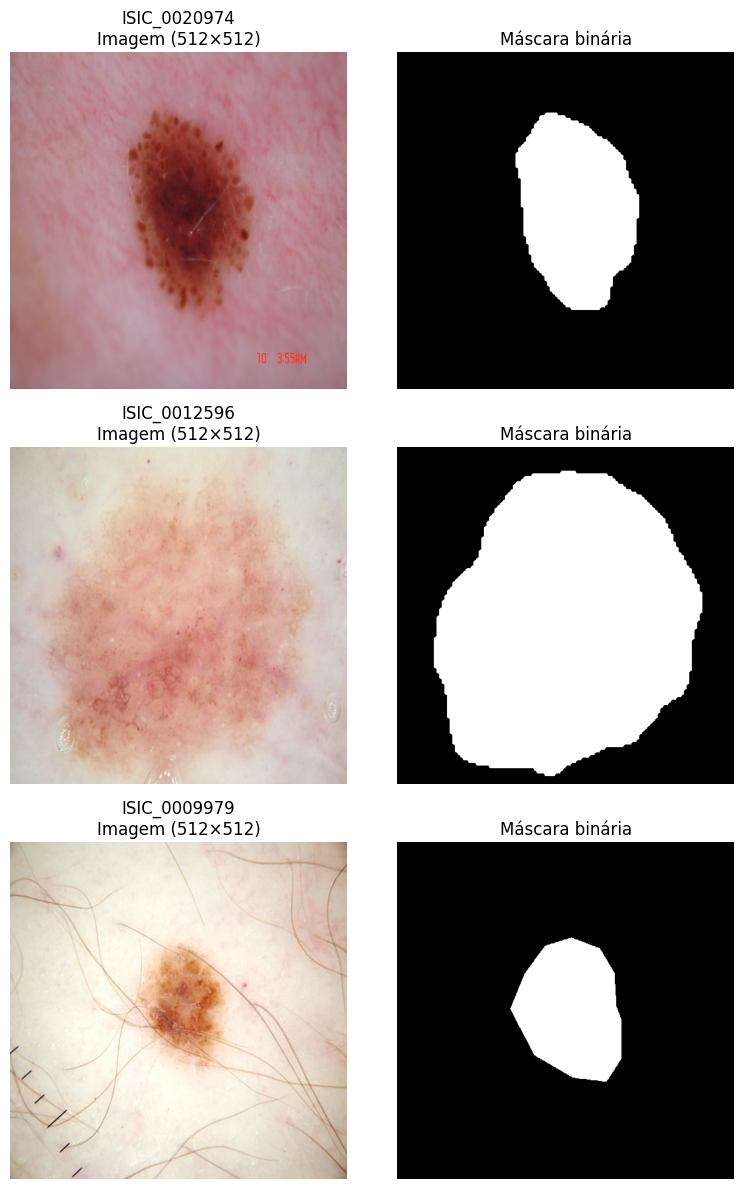

Imagem : (512, 512, 3)   (esperado 512×512×3)
Mask: (512, 512)  (expected 512×512)
Unique values in mask: [  0 255]


In [7]:
# ─── Visual verification of samples ───────────────────────────────────────────
import matplotlib.pyplot as plt

sample_ids = train_ids[:3]
fig, axes  = plt.subplots(len(sample_ids), 2, figsize=(8, 4 * len(sample_ids)))

for i, img_id in enumerate(sample_ids):
    img  = cv2.cvtColor(cv2.imread(os.path.join(IMG_OUT_DIR,  f'{img_id}.png')), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(os.path.join(MASK_OUT_DIR, f'{img_id}.png'), cv2.IMREAD_GRAYSCALE)

    axes[i, 0].imshow(img);  axes[i, 0].set_title(f'{img_id}\nImagem ({IMG_SIZE}×{IMG_SIZE})'); axes[i, 0].axis('off')
    axes[i, 1].imshow(mask, cmap='gray'); axes[i, 1].set_title('Binary mask'); axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

# Checagem de sanidade
s_img  = cv2.imread(os.path.join(IMG_OUT_DIR,  f'{sample_ids[0]}.png'))
s_mask = cv2.imread(os.path.join(MASK_OUT_DIR, f'{sample_ids[0]}.png'), cv2.IMREAD_GRAYSCALE)
print(f'Imagem : {s_img.shape}   (esperado {IMG_SIZE}×{IMG_SIZE}×3)')
print(f'Mask: {s_mask.shape}  (expected {IMG_SIZE}×{IMG_SIZE})')
print(f'Unique values in mask: {np.unique(s_mask)}')

## Output structure

```
UNeXt-pytorch-main/inputs/ISIC/
├── images/
│   ├── ISIC_0012255.png
│   ├── ISIC_0012346.png
│   └── ...
├── masks/
│   └── 0/
│       ├── ISIC_0012255.png
│       ├── ISIC_0012346.png
│       └── ...
├── train_ids.txt
├── val_ids.txt
└── test_ids.txt
```

Images and masks at **512×512 px** (PNG).  
Binary masks: values {0, 255}.